In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import torch
from torch import nn
from torch.utils.data import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU available: ", torch.cuda.is_available())

save_dir = "Data"

GPU available:  True


In [19]:
class MyDataset(Dataset):
    def __init__(self, data, target, transform=None, target_transform=None):
        self.data = data
        self.target = target
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        x = self.data[index]
        if self.transform:
            x = self.transform(x)

        y = self.target[index]
        if self.target_transform:
            y = self.target_transform(y)

        return x, y

# Download Image dataset

In [20]:
try:
    img = np.load(os.path.join(save_dir, 'Img.npy'))
    print("Image dataset loaded.")
except Exception as e:
    from sklearn.datasets import fetch_lfw_people
    min_faces_per_person = 30
    faces = fetch_lfw_people(min_faces_per_person=min_faces_per_person)
    print("Image dataset loaded from sklearn.")
    img = faces.images
    np.save(os.path.join(save_dir, 'Img.npy'), img)
    print("Image dataset saved.")

Image dataset loaded.


# Blur the images

In [21]:
# GaussianBlur(image, kernel size, sigma)
# sigma = 0 means that it is calculated from the kernel size
img_blurred = np.array([cv2.GaussianBlur(image, (5, 5), 0) for image in img]) 

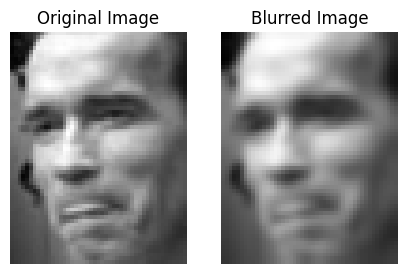

In [22]:
plt.figure(figsize=(5, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img[1], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Blurred Image")
plt.imshow(img_blurred[1], cmap='gray')
plt.axis('off')

plt.show()

# Convolution Neural Network

In [ ]:
from torch.utils.data import DataLoader

# Training function
def train(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss

# Testing function
def test(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / len(dataloader.dataset)
    
    return accuracy, avg_loss

# Create datasets and dataloaders
# Replace with your actual training/test data and targets
train_dataset = MyDataset(train_data, train_targets)
test_dataset = MyDataset(test_data, test_targets)

main_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
main_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Define and train the CNN

cnn_backbone = nn.Sequential(
    nn.Conv2d(3, 8, 5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(8, 16, 5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(1296, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
)

# Define the classifier head
classifier_head = nn.Linear(64, 8)

# Stack the CNN backbone and classifier head using nn.Sequential
full_model = nn.Sequential(
    cnn_backbone,
    classifier_head
).to(device)

# Compare test accuracies of FCN and CNN

loss_fn = nn.CrossEntropyLoss()

learning_rate = 2*1e-3
optimizer = torch.optim.Adam(full_model.parameters(), lr=learning_rate)

epochs = 50
accuracy = []
test_loss = []
train_loss = []
for t in range(epochs):
    print(f"Epoch {t+1}\n")
    b = train(main_train_loader, full_model, loss_fn, optimizer)
    a = test(main_test_loader, full_model, loss_fn)

    accuracy.append(a[0])
    test_loss.append(a[1])
    train_loss.append(b)

print("Done!")

x = np.linspace(1,epochs)

plt.figure()
plt.plot(x, accuracy)
plt.title("Accuracy")
plt.xlabel("Number of epochs")

# Machine Learning

# Test the final CNN